### Regex, Confusion Matrix, and Regression for solving Usecases
    Simple combined example of regex, confusion matrix and regression in python
  

#### Problem Statement: 
##### Predict sales based on domain classification (personal/corporate)
        Description: Extract emails & sales from data and label emails as (corporate/ personal) and use label as ip to regression model
                     and predict sales. Evaluate the classification with ConfusionMatrix
        Inputs: 
            List of emails and sales amounts.
        Action Items:
            Use regex to extract email domains (e.g., gmail.com, yahoo.com)
            Classify each domain as personal or corporate
            Train a regression model to predict sales based on this classification
            Evaluate the classification with a confusion matrix
#### 🪜 Step-by-Step Plan
        1. Create sample data: emails + sales
        2. Use regex to extract domain from each email
        3. Label domain as "personal" or "corporate"
        4. Use this label as input to a regression model (simple encoding)
        5. Predict sales
        6. Use confusion matrix to compare predicted vs actual class labels

#### 🐍 Full Python Code

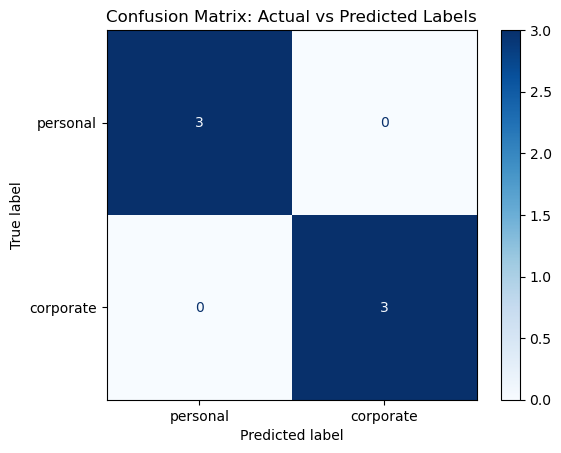

           domain      label  sales  predicted_sales predicted_label
0       gmail.com   personal    200       176.666667        personal
1     company.com  corporate    500       490.000000       corporate
2       yahoo.com   personal    150       176.666667        personal
3    business.org  corporate    450       490.000000       corporate
4     hotmail.com   personal    180       176.666667        personal
5  enterprise.com  corporate    520       490.000000       corporate


In [30]:
import re
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import sys

# Step 1: Sample data
data = [ ("john.doe@gmail.com", 200),("jane@company.com", 500),("mark@yahoo.com", 150),("lucy@business.org", 450),("alex@hotmail.com", 180),
    ("emma@enterprise.com", 520)]

df = pd.DataFrame(data, columns=["email", "sales"]) 

domain_regex = r"@((?:[\w-]+\.)+[\w]{2,7})"
# Step 2: Use regex to extract domain
df["domain"] = df["email"].apply(lambda x: re.findall(domain_regex, x)[0])

# Step 3: Classify domain as personal or corporate
personal_domains = {"gmail.com", "yahoo.com", "hotmail.com"}
df["label"] = df["domain"].apply(lambda d: "personal" if d in personal_domains else "corporate")


# Step 4: Encode label to use in regression
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])  # personal=1, corporate=0

X = df[['label_encoded']]
y = df['sales']

model = LinearRegression()
model.fit(X, y)
df['predicted_sales'] = model.predict(X)

# Step 5: Train regression model
X = df[["label_encoded"]]  # Only 1 feature: label
y = df["sales"]

model = LinearRegression()
model.fit(X, y)
df["predicted_sales"] = model.predict(X)

# Step 6: Turn regression output into predicted labels
df["predicted_label"] = df["predicted_sales"].apply(lambda s: "personal" if s < 250 else "corporate")

# Confusion Matrix
labels=["personal", "corporate"]

cm = confusion_matrix(df["label"], df["predicted_label"], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Actual vs Predicted Labels")
plt.show()

# Final output table
print(df[["domain", "label", "sales", "predicted_sales", "predicted_label"]])


#### Problem Statement: 
##### Predict review feedback 
    Description: Extract review rating from text as positive / negative if score > 3 positive else negative
        Inputs: 
            List of text and ratings.
        Action Items:
            Use regex to extract how many times the word “good” appears
            Use that number as a feature to predict the review score
            Convert predicted scores into "positive"/"negative" categories
            Evaluate with a confusion matrix

#### 🪜 Step-by-Step Plan
        Create sample data: text reviews + numerical ratings
        Use regex to count “good” occurrences
        Train regression to predict review score
        Convert scores into labels: positive (≥3) vs negative (<3)
        Use confusion matrix to evaluate label prediction

                            review  rating  predicted_rating actual_label  \
0                     This is good       4          3.304348     positive   
1  Really good product, good build       5          4.739130     positive   
2                  Not good at all       1          3.304348     negative   
3                        Just okay       3          1.869565     positive   
4              Terrible experience       1          1.869565     negative   
5                Good and reliable       4          3.304348     positive   
6            Bad quality, not good       2          3.304348     negative   
7             Excellent, just good       5          3.304348     positive   

  predicted_label  
0        positive  
1        positive  
2        positive  
3        negative  
4        negative  
5        positive  
6        positive  
7        positive  


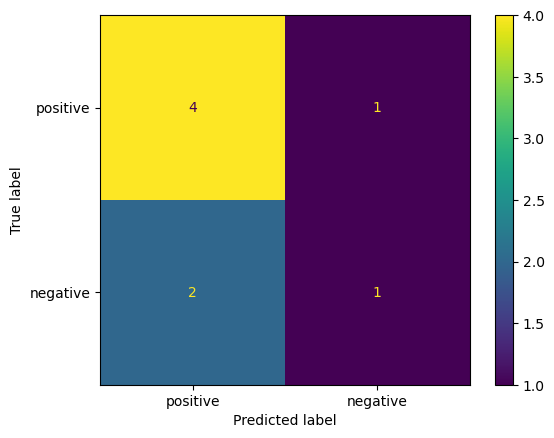

In [74]:
import re
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Sample review data
data = [ ("This is good", 4), ("Really good product, good build", 5), ("Not good at all", 1), ("Just okay", 3),("Terrible experience", 1),
    ("Good and reliable", 4), ("Bad quality, not good", 2), ("Excellent, just good", 5)]

df = pd.DataFrame(data, columns=["review", "rating"])

df['good_count'] = df['review'].apply(lambda x: len(re.findall(r"\bgood\b", x.lower())))

X = df[['good_count']]
y = df['rating']

model = LinearRegression()
model.fit(X, y)

df['predicted_rating'] = model.predict(X)

df['actual_label'] = df['rating'].apply(lambda x: "positive" if x >=3 else "negative")
df['predicted_label'] = df['predicted_rating'].apply(lambda x: "positive" if x >=3 else "negative")
labels = ["negative","positive"]
labels = ["positive","negative"]
cm = confusion_matrix(df['actual_label'], df['predicted_label'], labels =["positive","negative"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["positive","negative"])
disp.plot()

print(df[['review', 'rating', 'predicted_rating', 'actual_label', 'predicted_label']])


### Regex, Confusion Matrix, and Classification for solving a Usecase
    Inputs:
        email addresses with known labels:
            personal (e.g., Gmail, Yahoo, Hotmail)
            corporate (e.g., company emails)
    Action Items:
        Use regex to extract domains from emails
        Use that domain to train a classifier
        Evaluate it using a confusion matrix

#### 🪜 Step-by-Step Plan
    Create a dataset: email + label (personal/corporate)
    Use regex to extract email domain
    Use extracted domain to train a classifier (e.g., Decision Tree)
    Use classifier to make predictions
    Use confusion matrix to evaluate predictions

#### 🐍 Full Python Code

0         gmail.com
1       company.com
2         yahoo.com
3      business.org
4       hotmail.com
5    enterprise.com
6        startup.io
7         gmail.com
Name: domain, dtype: object


<Figure size 100x100 with 0 Axes>

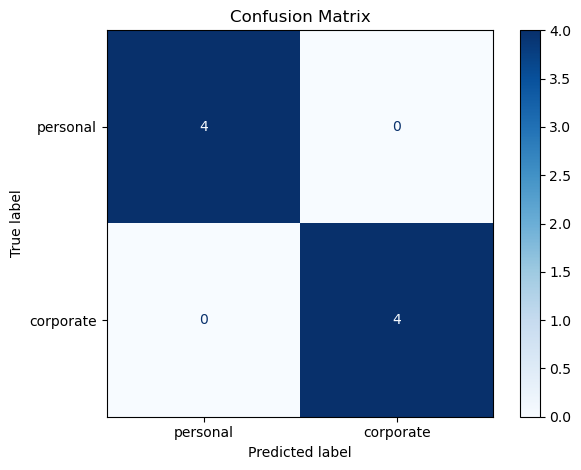

                 email          domain      label predicted_label
0   john.doe@gmail.com       gmail.com   personal        personal
1     jane@company.com     company.com  corporate       corporate
2       mark@yahoo.com       yahoo.com   personal        personal
3    lucy@business.org    business.org  corporate       corporate
4     alex@hotmail.com     hotmail.com   personal        personal
5  emma@enterprise.com  enterprise.com  corporate       corporate
6       bob@startup.io      startup.io  corporate       corporate
7       nina@gmail.com       gmail.com   personal        personal


In [13]:
import re
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Sample dataset
data = [ ("john.doe@gmail.com", "personal"), ("jane@company.com", "corporate"), ("mark@yahoo.com", "personal"), ("lucy@business.org", "corporate"),
    ("alex@hotmail.com", "personal"), ("emma@enterprise.com", "corporate"), ("bob@startup.io", "corporate"), ("nina@gmail.com", "personal")]

df = pd.DataFrame(data, columns=["email", "label"])

# Step 2: Extract domain using regex
domain_regex = r"@((?:[\w-]+\.)+[\w]{2,7})"
df["domain"] = df["email"].apply(lambda x: re.findall(domain_regex, x)[0])
print(df['domain'])

# Step 3: Encode domain and label to numbers
domain_encoder = LabelEncoder()
label_encoder = LabelEncoder()

df["domain_encoded"] = domain_encoder.fit_transform(df["domain"])
df["label_encoded"] = label_encoder.fit_transform(df["label"])

# Step 4: Train a classifier (Decision Tree for simplicity)
X = df[["domain_encoded"]]
y = df["label_encoded"]

clf = DecisionTreeClassifier()
clf.fit(X, y)

# Step 5: Predict and evaluate
df["predicted_label_encoded"] = clf.predict(X)
df["predicted_label"] = label_encoder.inverse_transform(df["predicted_label_encoded"])

# Step 6: Confusion Matrix
cm = confusion_matrix(df["label"], df["predicted_label"], labels=["personal", "corporate"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["personal", "corporate"])

plt.figure(figsize=(1, 1))  # Reduce figure size
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Show final dataframe
print(df[["email", "domain", "label", "predicted_label"]])




########**************************

 Inputs:
 
        email addresses with known labels:
            personal (e.g., Gmail, Yahoo, Hotmail)
            corporate (e.g., company emails)
            
    Action Items:
    
        Use regex to extract domains from emails
        Use that domain to train a classifier
        Evaluate it using a confusion matrix

##### PRACTICE WORK - START

              email          domain      label predicted_label
0     d.t@gmail.com       gmail.com   personal        personal
1     j@company.com     company.com  corporate       corporate
2       m@yahoo.com       yahoo.com   personal        personal
3    l@business.org    business.org  corporate       corporate
4     a@hotmail.com     hotmail.com   personal        personal
5  e@enterprise.com  enterprise.com  corporate       corporate
6      b@startup.io      startup.io  corporate       corporate
7       n@gmail.com       gmail.com   personal        personal


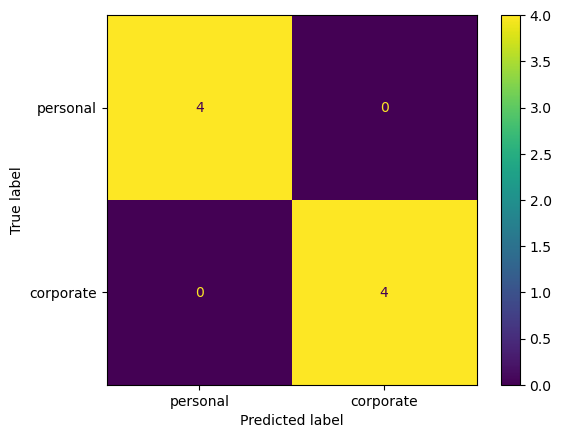

In [29]:
import re
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Step 1: Sample dataset
data = [ ("d.t@gmail.com", "personal"), ("j@company.com", "corporate"), ("m@yahoo.com", "personal"), ("l@business.org", "corporate"),
    ("a@hotmail.com", "personal"), ("e@enterprise.com", "corporate"), ("b@startup.io", "corporate"), ("n@gmail.com", "personal")]

df = pd.DataFrame(data, columns=["email", "label"])

domain_regex = r"@((?:[\w-]+\.)+[\w]{2,7})"
df['domain'] = df['email'].apply(lambda x: re.findall(domain_regex, x)[0])

domain_encoder = LabelEncoder(); label_encoder = LabelEncoder()
df['domain_encoded'] = domain_encoder.fit_transform(df['domain'])
df['label_encoded'] = label_encoder.fit_transform(df['label'])

X = df[['domain_encoded']]; y = df['label_encoded']
decision_classifier = DecisionTreeClassifier()
decision_classifier.fit(X,y)

df['predicted_label_encoded'] = decision_classifier.predict(X)
df['predicted_label'] = label_encoder.inverse_transform(df['predicted_label_encoded'])

print(df[["email", "domain", "label", "predicted_label"]])
cat_labels = ["personal", "corporate"]

cm = confusion_matrix(df["label"], df["predicted_label"], labels=cat_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cat_labels)
disp.plot()


In [38]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
# Step 1: Sample data
data = [ ("john.doe@gmail.com", 200),("jane@company.com", 500),("mark@yahoo.com", 150),("lucy@business.org", 450),("alex@hotmail.com", 180),
    ("emma@enterprise.com", 520)]

df = pd.DataFrame(data, columns=["email", "sales"])

domain_regex = r"@((?:[\w-]+\.)+[\w]{2,7})"
df['domain'] = df['email'].apply(lambda x: re.findall(domain_regex, x)[0])

domain_encoder = LabelEncoder()
sales_encoder = LabelEncoder()

df['domain_encoded'] = domain_encoder.fit_transform(df['domain'])
df['sales_encoded'] = sales_encoder.fit_transform(df['sales'])

X = df[['domain_encoded']]
y = df['sales_encoded']

model = DecisionTreeClassifier()
model.fit(X,y)

df['predicted_sales_encoded'] = model.predict(X)
df['predicted_sales'] = sales_encoder.inverse_transform(df['predicted_sales_encoded'])
print(df[["email", "domain", "sales", "predicted_sales"]])






                 email          domain  sales  predicted_sales
0   john.doe@gmail.com       gmail.com    200              200
1     jane@company.com     company.com    500              500
2       mark@yahoo.com       yahoo.com    150              150
3    lucy@business.org    business.org    450              450
4     alex@hotmail.com     hotmail.com    180              180
5  emma@enterprise.com  enterprise.com    520              520


                      email  sales domain_type predicted_domain_type
0  john.doe@gmail.com.co.in    200    personal              personal
1          jane@company.com    500   corporate             corporate
2            mark@yahoo.com    150    personal              personal
3         lucy@business.org    450   corporate             corporate
4          alex@hotmail.com    180    personal              personal
5       emma@enterprise.com    520   corporate             corporate


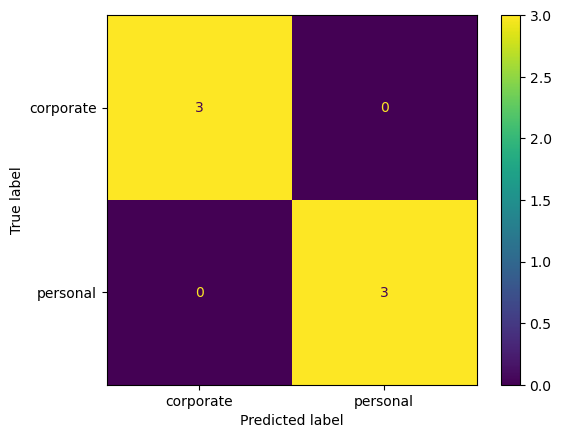

In [58]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
# Step 1: Sample data
data = [ ("john.doe@gmail.com.co.in", 200),("jane@company.com", 500),("mark@yahoo.com", 150),("lucy@business.org", 450),("alex@hotmail.com", 180),
    ("emma@enterprise.com", 520)]

df = pd.DataFrame(data, columns=["email", "sales"])

domain_regex = r"@((?:[\w-]+\.)+[\w]{2,7})"
df['domain'] = df['email'].apply(lambda x: re.findall(domain_regex, x)[0])

personal_domains = {"gmail.com.co.in","gmail.com", "yahoo.com", "hotmail.com"}

df['domain_type'] = df['domain'].apply(lambda x: "personal" if x in personal_domains  else "corporate")

domain_encoder = LabelEncoder()
df['domain_type_encoded'] = domain_encoder.fit_transform(df['domain_type'])

X = df[['domain_type_encoded']]; y = df['sales']
model = LinearRegression(); model.fit(X,y)
df['predicted_sales'] = model.predict(X)
df['predicted_domain_type'] = df['predicted_sales'].apply(lambda x: "personal" if x < 225 else "corporate")

print(df[["email", "sales", "domain_type", "predicted_domain_type"]])

labels = ["corporate","personal"]
cm = confusion_matrix(df['domain_type'], df['predicted_domain_type'], labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot()



##### PRACTICE WORK --- END 

#### Problem Statement:
     sample program with regex , features extraction and classification for movie cost in Rupees
     Movie Features:
        cast salary in detail like Actor , Actress , Story Writer, Other Cast, Music Director , Action Director etc 
        Pre production 
        Post production,      
        Re recording,
        VFX,
        Travel Expenses,
        Dubbing, 
        Marketing & Promotions 
        Miscellaneous tasks 
        first in steps and 
        then in python code

In [204]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Step 1: Simulated raw text data in INR
raw_data = [
    "Actor: ₹50L, Actress: ₹40L, Writer: ₹10L, Music Director: ₹15L, Action Director: ₹20L, Other Cast: ₹5L, Pre-prod: ₹30L, Post-prod: ₹40L, VFX: ₹1.5Cr, Re-rec: ₹10L, Travel: ₹5L, Dubbing: ₹10L, Marketing: ₹70L, Misc: ₹5L",
    "Actor: ₹20L, Actress: ₹15L, Writer: ₹5L, Music Director: ₹8L, Action Director: ₹10L, Other Cast: ₹3L, Pre-prod: ₹10L, Post-prod: ₹12L, VFX: ₹40L, Re-rec: ₹5L, Travel: ₹3L, Dubbing: ₹5L, Marketing: ₹20L, Misc: ₹2L",
    "Actor: ₹1Cr, Actress: ₹80L, Writer: ₹25L, Music Director: ₹35L, Action Director: ₹40L, Other Cast: ₹10L, Pre-prod: ₹50L, Post-prod: ₹60L, VFX: ₹3Cr, Re-rec: ₹15L, Travel: ₹10L, Dubbing: ₹20L, Marketing: ₹1Cr, Misc: ₹8L",
    "Actor: ₹60L, Actress: ₹50L, Writer: ₹12L, Music Director: ₹18L, Action Director: ₹25L, Other Cast: ₹6L, Pre-prod: ₹25L, Post-prod: ₹35L, VFX: ₹1Cr, Re-rec: ₹8L, Travel: ₹4L, Dubbing: ₹12L, Marketing: ₹60L, Misc: ₹3L",
    "Actor: ₹15L, Actress: ₹10L, Writer: ₹5L, Music Director: ₹6L, Action Director: ₹8L, Other Cast: ₹2L, Pre-prod: ₹8L, Post-prod: ₹10L, VFX: ₹20L, Re-rec: ₹3L, Travel: ₹2L, Dubbing: ₹3L, Marketing: ₹10L, Misc: ₹1L",
]

# Step 2: Regex-based parser for INR values
def parse_inr(text):
    # Patterns: ₹50L, ₹1.5Cr etc.
    pattern = r'([\w\s]+):\s*₹([\d.]+)([LCr]+)?'
    matches = re.findall(pattern, text)

    inr_map = {}
    for key, value, unit in matches:
        multiplier = 1
        unit = unit.strip() if unit else ""
        if unit == 'L':
            multiplier = 1_00_000
        elif unit == 'Cr':
            multiplier = 1_00_00_000
        val_in_inr = float(value) * multiplier
        inr_map[key.strip()] = val_in_inr
    return inr_map

# Step 3: Feature extraction
rows = []
for entry in raw_data:
    parsed = parse_inr(entry)
    # Fill missing keys with 0
    keys = ['Actor', 'Actress', 'Writer', 'Other Cast', 'Music Director', 'Action Director',
            'Pre-prod', 'Post-prod', 'Re-rec', 'VFX', 'Travel', 'Dubbing', 'Marketing', 'Misc']
    row = {key: parsed.get(key, 0) for key in keys}
    rows.append(row)

df = pd.DataFrame(rows)

# Step 4: Add Total and Labels
df['Total'] = df.sum(axis=1)
df['Cost_Class'] = pd.cut(
    df['Total'],
    bins=[0, 2_00_00_000, 5_00_00_000, 100_00_00_000],  # ₹2Cr and ₹5Cr thresholds
    labels=['Low', 'Medium', 'High']
)

# Step 5: ML Classification
X = df.drop(columns=['Total', 'Cost_Class'])
y = df['Cost_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Output
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nSample Predictions:\n")
print(X_test.assign(Predicted=y_pred, Actual=y_test))


Classification Report:

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


Sample Predictions:

       Actor    Actress    Writer  Other Cast  Music Director  ...   Dubbing  Marketing      Misc  Predicted  Actual
1  2000000.0  1500000.0  500000.0    300000.0        800000.0  ...  500000.0  2000000.0  200000.0        Low     Low

[1 rows x 16 columns]


#### Problem Statement:
     Sample program with regex , features extraction and prediction of expenses a family in Rupees
     Family Expenses:
        Rent
        Petrol
        Gas Cylinder
        Current Bill
        School Fees
        College Fees
        Food Item Expenses (Curries, Dal , Oil )
        Health Insurance Policy
        Mobile Bill 
        Internet Bill
        Miscallaneous Expenses
        first in steps and 
        then in python code
        
        
        

In [262]:
import pandas as pd
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 1: Simulated raw data
raw_data = [
    "Rent: ₹12000, Petrol: ₹4000, Gas Cylinder: ₹1200, Current: ₹900, School Fees: ₹3500, Curries: ₹2000, Dal: ₹500, Oil: ₹600, Health: ₹2000, Mobile: ₹800, Internet: ₹1000, Misc: ₹1200",
    "Rent: ₹10000, Petrol: ₹3000, Gas Cylinder: ₹1100, Current: ₹850, School Fees: ₹3000, Curries: ₹1800, Dal: ₹400, Oil: ₹500, Health: ₹1500, Mobile: ₹700, Internet: ₹900, Misc: ₹1000",
    "Rent: ₹15000, Petrol: ₹5000, Gas Cylinder: ₹1300, Current: ₹1000, College Fees: ₹8000, Curries: ₹2500, Dal: ₹600, Oil: ₹700, Health: ₹2500, Mobile: ₹900, Internet: ₹1200, Misc: ₹1500",
    "Rent: ₹11000, Petrol: ₹3500, Gas Cylinder: ₹1150, Current: ₹870, School Fees: ₹3200, Curries: ₹2100, Dal: ₹450, Oil: ₹550, Health: ₹1800, Mobile: ₹750, Internet: ₹950, Misc: ₹1100",
    "Rent: ₹9000, Petrol: ₹2500, Gas Cylinder: ₹1000, Current: ₹800, School Fees: ₹2800, Curries: ₹1500, Dal: ₹300, Oil: ₹400, Health: ₹1000, Mobile: ₹600, Internet: ₹850, Misc: ₹900"
]

# Step 2: Define regex parser
def parse_expenses(text):
    pattern = r'([\w\s]+):\s*₹([\d,]+)'
    matches = re.findall(pattern, text)

    # Normalized categories
    expense = {
        'Rent': 0,
        'Petrol': 0,
        'Gas Cylinder': 0,
        'Current Bill': 0,
        'School Fees': 0,
        'College Fees': 0,
        'Food Expenses': 0,
        'Health Insurance Policy': 0,
        'Mobile Bill': 0,
        'Internet Bill': 0,
        'Miscellaneous Expenses': 0
    }

    for label, amount in matches:
        clean_label = label.strip().lower()
        amount = int(amount.replace(',', ''))

        if clean_label in ['rent']:
            expense['Rent'] += amount
        elif clean_label in ['petrol']:
            expense['Petrol'] += amount
        elif 'gas' in clean_label:
            expense['Gas Cylinder'] += amount
        elif 'current' in clean_label:
            expense['Current Bill'] += amount
        elif 'school' in clean_label:
            expense['School Fees'] += amount
        elif 'college' in clean_label:
            expense['College Fees'] += amount
        elif clean_label in ['curries', 'dal', 'oil']:
            expense['Food Expenses'] += amount
        elif 'health' in clean_label:
            expense['Health Insurance Policy'] += amount
        elif 'mobile' in clean_label:
            expense['Mobile Bill'] += amount
        elif 'internet' in clean_label:
            expense['Internet Bill'] += amount
        elif 'misc' in clean_label:
            expense['Miscellaneous Expenses'] += amount

    return expense

# Step 3: Feature extraction
rows = []
totals = []

for entry in raw_data:
    parsed = parse_expenses(entry)
    total = sum(parsed.values())
    rows.append(parsed)
    totals.append(total)

df = pd.DataFrame(rows)
print(df.columns)
df['Total_Expenses'] = totals
print(df

# Step 4: Train regression model
X = df.drop(columns=['Total_Expenses'])
y = df['Total_Expenses']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Step 5: Evaluate
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("\nPredicted vs Actual:\n")
result = pd.DataFrame({'Predicted': y_pred, 'Actual': y_test.values})
print(result)


Index(['Rent', 'Petrol', 'Gas Cylinder', 'Current Bill', 'School Fees',
       'College Fees', 'Food Expenses', 'Health Insurance Policy',
       'Mobile Bill', 'Internet Bill', 'Miscellaneous Expenses'],
      dtype='object')
    Rent  Petrol  Gas Cylinder  Current Bill  ...  Mobile Bill  Internet Bill  Miscellaneous Expenses  Total_Expenses
0  12000    4000          1200           900  ...          800           1000                    1200           29700
1  10000    3000          1100           850  ...          700            900                    1000           24750
2  15000    5000          1300          1000  ...          900           1200                    1500           40200
3  11000    3500          1150           870  ...          750            950                    1100           27420
4   9000    2500          1000           800  ...          600            850                     900           21650

[5 rows x 12 columns]
Mean Squared Error: 6659.721324097955

Pre

#### Sample program with regex , features extraction and prediction of first day Movie revenue in India by Theatres Release with below details 
#### with approximate 11,000 theatres across different cities and towns of different states in India 
      Details:
        Theatre_Name
        Theatre_Type
        Total_Theatre_Seats_Capacity
		Theatre_Max_Price_Seats_Capacity
		Theatre_Min_Price_Seats_Capacity
		State
		City/Town/Village Name
		City/Town/Village Type (C for City, T for Town, V for Village)
        Max_Shows_Allowed_Per_Day
		Ticket_Price_Max
		Ticket_Price_Min
		
	   Criteria: Max_Price should not exceed 250 in town
				 Min_Price should not exceed 125 in town
				 Max_Price should not exceed 500 in city
				 Min_Price should not exceed 150 in city
				 Max_Price should not exceed 175 in village
				 Min_Price should not exceed  75 in village
				 Seats Capacity should not exceed 300 
				 Min Price Seats should not exceed 10 % of Seat capacity
				 Max_Shows_Allowed_Per_Day should not exceed 6 and should not fall below 3
		
		using random values and faker 
		
		first explain in steps and then in python

In [363]:
import pandas as pd
import random
import re
from faker import Faker
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

fake = Faker('en_IN')
random.seed(42)

# Constraints per region type
constraints = {
    'C': {'max_price': 700, 'min_price': 200},
    'T': {'max_price': 250, 'min_price': 125},
    'V': {'max_price': 175, 'min_price': 75}
}

def generate_data(city_type, count):
    data = []
    theatre_types = ['Multiplex', 'Single Screen', 'Mini', 'IMAX']

    for _ in range(count):
        state = fake.state()
        city = fake.city()
        theatre_name = fake.company()
        theatre_type = random.choice(theatre_types)

        total_seats = random.randint(100, 400)
        min_price_seats = random.randint(0, int(0.10 * total_seats))  # ≤ 10%
        max_price_seats = total_seats - min_price_seats

        max_shows = random.randint(3, 6)

        max_price = random.randint(constraints[city_type]['min_price'] + 10, constraints[city_type]['max_price'])
        min_price = random.randint(50, constraints[city_type]['min_price'])

        # Generate raw string
        raw_string = f"Theatre: {theatre_name}, Max Seats: {max_price_seats}, Min Seats: {min_price_seats}, Price ₹{max_price}/₹{min_price}"

        # Apply regex to extract
        match = re.search(r"Max Seats:\s*(\d+), Min Seats:\s*(\d+), Price ₹(\d+)/₹(\d+)", raw_string)
        if not match:
            continue

        max_seats_r = int(match.group(1))
        min_seats_r = int(match.group(2))
        max_price_r = int(match.group(3))
        min_price_r = int(match.group(4))

        # Revenue calculation
        revenue = (max_seats_r * max_price_r + min_seats_r * min_price_r) * max_shows

        data.append({
            "Theatre_Name": theatre_name,
            "Theatre_Type": theatre_type,
            "Total_Theatre_Seats_Capacity": total_seats,
            "Theatre_Max_Price_Seats_Capacity": max_seats_r,
            "Theatre_Min_Price_Seats_Capacity": min_seats_r,
            "State": state,
            "City": city,
            "City_Type": city_type,
            "Max_Shows_Allowed_Per_Day": max_shows,
            "Ticket_Price_Max": max_price_r,
            "Ticket_Price_Min": min_price_r,
            "First_Day_Revenue": revenue
        })
    return data

# Step 1: Generate all records
city_data = generate_data('C', 6600)
town_data = generate_data('T', 3300)
village_data = generate_data('V', 1100)

# Combine
all_data = city_data + town_data + village_data
df = pd.DataFrame(all_data)

df.to_csv(r"D:\Career-Related\Trainings\ETLHive-Training-Content\Python\Python-ETL-Workspace\ml-combination-samples\dummy_theatres.csv", index=False)

# Step 2: Encode categorical columns
df_encoded = pd.get_dummies(df, columns=["Theatre_Type", "City_Type", "State"], drop_first=True)

# Step 3: Feature matrix and target
X = df_encoded.drop(columns=["Theatre_Name", "City", "First_Day_Revenue"])
y = df_encoded["First_Day_Revenue"]

# Step 4: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train regression model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 6: Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n📊 Mean Absolute Error: ₹{int(mae):,}")

# Show sample predictions
sample_df = pd.DataFrame({
    "Predicted_Revenue": y_pred[:10],
    "Actual_Revenue": y_test.values[:10]
})
print("\n🔍 Sample Predictions:\n")
print(sample_df)



📊 Mean Absolute Error: ₹5,598

🔍 Sample Predictions:

   Predicted_Revenue  Actual_Revenue
0          229103.16          227331
1          447030.24          447180
2           90434.36           92460
3          183447.87          180756
4         1169229.10         1224700
5          288441.32          293372
6          685571.28          688140
7          188763.75          189216
8          329162.97          331920
9          152453.44          149528


#### Read from existing dummy theatres data

In [364]:
import pandas as pd
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

df = pd.read_csv(r"D:\Career-Related\Trainings\ETLHive-Training-Content\Python\Python-ETL-Workspace\ml-combination-samples\dummy_theatres.csv")
# One-hot encode categorical fields
df_encoded = pd.get_dummies(df, columns=["Theatre_Type", "City_Type", "State"], drop_first=True)

# Define features and target
X = df_encoded.drop(columns=["Theatre_Name", "City", "First_Day_Revenue"])
y = df_encoded["First_Day_Revenue"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n📊 Mean Absolute Error: ₹{int(mae):,}\n")

# Display sample predictions
sample_df = pd.DataFrame({
    'Predicted_Revenue': y_pred[:10],
    'Actual_Revenue': y_test.values[:10]
})
print("🔍 Sample Predictions:\n")
print(sample_df)


📊 Mean Absolute Error: ₹5,598

🔍 Sample Predictions:

   Predicted_Revenue  Actual_Revenue
0          229103.16          227331
1          447030.24          447180
2           90434.36           92460
3          183447.87          180756
4         1169229.10         1224700
5          288441.32          293372
6          685571.28          688140
7          188763.75          189216
8          329162.97          331920
9          152453.44          149528


In [383]:
val = sum(df['First_Day_Revenue'])
capacity = 1
str(round((val * capacity)/1_00_00_000, 2))+" Crores"


'405.23 Crores'

In [366]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Theatre_Seats_Capacity,11000.0,248.569364,87.164758,100.0,172.0,248.0,324.00,400.0
Theatre_Max_Price_Seats_Capacity,11000.0,236.424636,83.214284,90.0,164.0,236.0,308.00,400.0
Theatre_Min_Price_Seats_Capacity,11000.0,12.144727,8.856841,0.0,5.0,10.0,18.00,39.0
Max_Shows_Allowed_Per_Day,11000.0,4.483000,1.123391,3.0,3.0,4.0,5.00,6.0
Ticket_Price_Max,11000.0,343.203545,176.657981,85.0,192.0,290.0,496.00,700.0
Ticket_Price_Min,11000.0,107.737364,42.366186,50.0,71.0,100.0,137.00,200.0
First_Day_Revenue,11000.0,368387.417636,260789.207673,24990.0,178545.5,292872.0,485190.75,1615440.0


In [290]:
df.columns


Index(['Theatre_Name', 'Theatre_Type', 'Total_Theatre_Seats_Capacity',
       'Theatre_Max_Price_Seats_Capacity', 'Theatre_Min_Price_Seats_Capacity',
       'State', 'City', 'City_Type', 'Max_Shows_Allowed_Per_Day',
       'Ticket_Price_Max', 'Ticket_Price_Min', 'First_Day_Revenue'],
      dtype='object')

In [367]:
state_theatre_count = (
    df.groupby(by=["State"]).agg(Theatre_Count = ("Theatre_Name", "count")).sort_values(by =["State"], ascending=True).head(1)
)
state_theatre_count

,Theatre_Count
State,
Andhra Pradesh,363


In [368]:
max_theatre_state = (
    df.groupby(by=["State"]).agg(Theatre_Count = ("Theatre_Name", "count")).sort_values(by =["Theatre_Count"], ascending=False).head(1)
)
max_theatre_state

,Theatre_Count
State,
Uttarakhand,429


In [369]:
min_theatre_state = (
    df.groupby(by=["State"]).agg(Theatre_Count = ("Theatre_Name", "count")).sort_values(by =["Theatre_Count"], ascending=True).head(1)
)
min_theatre_state

,Theatre_Count
State,
Karnataka,343


In [370]:
top_5_first_day_revenue_theatres = (
    df.sort_values(by = ["First_Day_Revenue"], ascending=False)[["State", "Theatre_Name", "First_Day_Revenue"]].head(5).reset_index(drop=True)
)
top_5_first_day_revenue_theatres

,State,Theatre_Name,First_Day_Revenue
0,Nagaland,"Bava, Samra and Natt",1615440
1,West Bengal,Kohli Ltd,1586658
2,Punjab,"Raval, Tata and Rama",1578378
3,Bihar,Devan-Dhawan,1537992
4,Himachal Pradesh,"Khalsa, Sharma and Walia",1536096


In [371]:
bottom_5_first_day_revenue_theatres = (
    df.sort_values(by = ["First_Day_Revenue"], ascending=False)[["State", "Theatre_Name", "First_Day_Revenue"]].tail(5).reset_index(drop=True)
)
bottom_5_first_day_revenue_theatres

,State,Theatre_Name,First_Day_Revenue
0,Jharkhand,Chhabra Group,29640
1,Tripura,Mani and Sons,28122
2,Punjab,"Ghosh, Acharya and Sarma",26832
3,West Bengal,Raju-Amble,26640
4,Mizoram,Gour PLC,24990


In [342]:
df.head(1)

,Theatre_Name,Theatre_Type,Total_Theatre_Seats_Capacity,Theatre_Max_Price_Seats_Capacity,Theatre_Min_Price_Seats_Capacity,State,City,City_Type,Max_Shows_Allowed_Per_Day,Ticket_Price_Max,Ticket_Price_Min,First_Day_Revenue
0,"Rana, Kashyap and Chanda",Multiplex,106,102,4,Sikkim,Cuttack,V,4,116,57,48240


In [372]:
top_5_max_capacity_theatres= (
    df.sort_values(by=["Total_Theatre_Seats_Capacity"], ascending=False)[["State", "Theatre_Name", "Total_Theatre_Seats_Capacity"]].head(5).reset_index(drop=True)
)
top_5_max_capacity_theatres

,State,Theatre_Name,Total_Theatre_Seats_Capacity
0,Madhya Pradesh,Jayaraman-Aggarwal,400
1,West Bengal,Kari PLC,400
2,Goa,Subramaniam Group,400
3,West Bengal,"Rama, Hora and Shukla",400
4,Chhattisgarh,De-Ahuja,400


In [373]:
bottom_5_max_capacity_theatres= (
    df.sort_values(by=["Total_Theatre_Seats_Capacity"], ascending=False)[["State", "Theatre_Name", "Total_Theatre_Seats_Capacity"]].tail(5).reset_index(drop=True)
)
bottom_5_max_capacity_theatres

,State,Theatre_Name,Total_Theatre_Seats_Capacity
0,Tamil Nadu,Khanna-Singh,100
1,Kerala,"Taneja, Vala and Sodhi",100
2,Goa,"Rana, Mishra and Palla",100
3,West Bengal,"Sule, Naik and Vaidya",100
4,Goa,"Chanda, Sekhon and Jani",100


In [374]:
theatres_by_city = (
     df.query("City_Type == 'C'")[["State", "City", "Theatre_Name"]].sort_values(by="State").reset_index(drop=True)
)
theatres_by_city

,State,City,Theatre_Name
0,Andhra Pradesh,Solapur,Rajagopal-Ganguly
1,Andhra Pradesh,Berhampur,Bora-Baria
2,Andhra Pradesh,Belgaum,Contractor-Raman
3,Andhra Pradesh,Hindupur,"Khare, Thaman and Sane"
4,Andhra Pradesh,Panchkula,Chacko-Tandon
...,...,...,...
6595,West Bengal,Nellore,"Sehgal, Devan and Johal"
6596,West Bengal,Giridih,"Gaba, Kant and Luthra"
6597,West Bengal,Rajahmundry,Bora Inc
6598,West Bengal,Kanpur,Chowdhury-Rajagopalan


In [375]:
theatres_by_village = (
     df.query("City_Type == 'V'")[["State", "City", "Theatre_Name"]].sort_values(by="State").reset_index(drop=True)
)
theatres_by_village

,State,City,Theatre_Name
0,Andhra Pradesh,Khora,Tata-Hayre
1,Andhra Pradesh,Thanjavur,Dyal-Sachdev
2,Andhra Pradesh,Patiala,Koshy Inc
3,Andhra Pradesh,Satna,Hans-Khosla
4,Andhra Pradesh,Darbhanga,"Choudhury, Ahluwalia and Ramanathan"
...,...,...,...
1095,West Bengal,Uluberia,"Prabhu, Sarna and Ranganathan"
1096,West Bengal,Barasat,"Upadhyay, Salvi and Choudhury"
1097,West Bengal,Panipat,Modi Group
1098,West Bengal,Jodhpur,Batta-Shan


In [376]:
theatres_by_town = (
     df.query("City_Type == 'T'")[["State", "City", "Theatre_Name"]].sort_values(by="State").reset_index(drop=True)
)
theatres_by_town

,State,City,Theatre_Name
0,Andhra Pradesh,South Dumdum,Raja Ltd
1,Andhra Pradesh,Secunderabad,Wadhwa and Sons
2,Andhra Pradesh,Deoghar,"Dewan, Parmer and Jha"
3,Andhra Pradesh,Jabalpur,"Doshi, Kulkarni and Gara"
4,Andhra Pradesh,Shimla,Yohannan-Dua
...,...,...,...
3295,West Bengal,Amaravati,Pillay-Panchal
3296,West Bengal,Raiganj,Iyer-Tiwari
3297,West Bengal,Aurangabad,Rai Inc
3298,West Bengal,Ahmednagar,Sinha-Agarwal


In [388]:
top_5_min_price_theatres = (
    df.sort_values(by=["Ticket_Price_Min"], ascending=True)
    [["State", "City", "Theatre_Name", "Ticket_Price_Max", "Ticket_Price_Min"]].reset_index(drop=True).head(5)             
)
top_5_min_price_theatres

,State,City,Theatre_Name,Ticket_Price_Max,Ticket_Price_Min
0,Gujarat,Baranagar,"Hayer, Kari and Sant",87,50
1,Punjab,Belgaum,"Kadakia, Chander and Divan",114,50
2,Tamil Nadu,Kavali,Bhakta LLC,531,50
3,Arunachal Pradesh,Gudivada,Chopra and Sons,164,50
4,Karnataka,Aligarh,Saini Ltd,242,50


In [412]:
top_5_min_price_theatres_by_state = (
    df.sort_values(by=["State", "Ticket_Price_Min"]).groupby("State").head(5).reset_index(drop=True)
)
top_5_min_price_theatres_by_state

,Theatre_Name,Theatre_Type,Total_Theatre_Seats_Capacity,Theatre_Max_Price_Seats_Capacity,Theatre_Min_Price_Seats_Capacity,State,City,City_Type,Max_Shows_Allowed_Per_Day,Ticket_Price_Max,Ticket_Price_Min,First_Day_Revenue
0,Verma-Bhatt,IMAX,266,247,19,Andhra Pradesh,Ulhasnagar,T,3,140,50,106590
1,"Deo, Bhat and Doctor",IMAX,129,126,3,Andhra Pradesh,Surendranagar Dudhrej,T,3,229,50,87012
2,Chandra-Rajagopalan,Mini,351,344,7,Andhra Pradesh,Mehsana,V,4,146,50,202296
3,"Din, Khalsa and Sem",IMAX,399,398,1,Andhra Pradesh,Hindupur,C,6,454,51,1084458
4,Cherian Inc,Multiplex,319,298,21,Andhra Pradesh,Kolhapur,C,3,279,51,252639
...,...,...,...,...,...,...,...,...,...,...,...,...
135,"Karpe, Radhakrishnan and Vyas",Mini,165,155,10,West Bengal,Gulbarga,C,6,505,50,472650
136,Dutt-Ghose,Mini,275,250,25,West Bengal,Bhubaneswar,C,5,382,50,483750
137,Gala-Dora,Single Screen,164,153,11,West Bengal,Dhanbad,C,6,635,50,586230
138,Dada-Walla,Single Screen,262,244,18,West Bengal,Sonipat,T,6,141,50,211824


In [414]:
highest_5_min_prices_by_state = (
    df.sort_values(by=["State", "Ticket_Price_Min"], ascending=[True, False]).groupby("State").head(5).reset_index(drop=True)
)
highest_5_min_prices_by_state

,Theatre_Name,Theatre_Type,Total_Theatre_Seats_Capacity,Theatre_Max_Price_Seats_Capacity,Theatre_Min_Price_Seats_Capacity,State,City,City_Type,Max_Shows_Allowed_Per_Day,Ticket_Price_Max,Ticket_Price_Min,First_Day_Revenue
0,"Dayal, Pal and Bassi",IMAX,176,165,11,Andhra Pradesh,Durg,C,6,324,200,333960
1,Korpal PLC,Single Screen,390,352,38,Andhra Pradesh,Singrauli,C,5,584,199,1065650
2,"Balakrishnan, Patla and Bail",IMAX,285,274,11,Andhra Pradesh,Vijayawada,C,3,365,198,306564
3,Sami LLC,Multiplex,152,140,12,Andhra Pradesh,Kakinada,C,5,661,198,474580
4,Jani Inc,IMAX,289,282,7,Andhra Pradesh,Alwar,C,4,417,198,475920
...,...,...,...,...,...,...,...,...,...,...,...,...
135,"Bala, Panchal and Virk",IMAX,295,279,16,West Bengal,Tumkur,C,4,467,200,533972
136,"Kaur, Dara and Balasubramanian",Single Screen,162,152,10,West Bengal,Silchar,C,5,636,199,493310
137,Contractor Group,IMAX,224,222,2,West Bengal,Asansol,C,5,315,199,351640
138,Kohli Ltd,Single Screen,395,388,7,West Bengal,Hapur,C,6,678,197,1586658


In [417]:
top_5_max_price_theatres = (
    df.sort_values(by=["Ticket_Price_Max"], ascending=[False])[["State", "City", "Theatre_Name", "Ticket_Price_Max"]].head(5)
)
top_5_max_price_theatres

,State,City,Theatre_Name,Ticket_Price_Max
6593,Himachal Pradesh,Nizamabad,"Bora, Pai and Setty",700
3430,Rajasthan,Saharanpur,Divan PLC,700
1418,Punjab,Karawal Nagar,Nazareth LLC,700
5366,Jharkhand,Patiala,Sampath PLC,700
2524,Madhya Pradesh,Bihar Sharif,Subramaniam Group,700


In [426]:
top_5_max_price_theatres_by_state = (
    df.sort_values(by=["State", "Ticket_Price_Max"], ascending=[True, False])
    .groupby("State").head(5).reset_index(drop=True)
)
top_5_max_price_theatres_by_state

,Theatre_Name,Theatre_Type,Total_Theatre_Seats_Capacity,Theatre_Max_Price_Seats_Capacity,Theatre_Min_Price_Seats_Capacity,State,City,City_Type,Max_Shows_Allowed_Per_Day,Ticket_Price_Max,Ticket_Price_Min,First_Day_Revenue
0,Saran Group,Mini,313,288,25,Andhra Pradesh,Machilipatnam,C,6,698,60,1215144
1,Shah Inc,Mini,307,299,8,Andhra Pradesh,Mirzapur,C,3,698,180,630426
2,"Kala, Mukherjee and Prabhu",Single Screen,390,385,5,Andhra Pradesh,Tinsukia,C,4,690,80,1064200
3,Mutti-Chaudhry,IMAX,398,362,36,Andhra Pradesh,Tumkur,C,5,688,116,1266160
4,Ratti-Bhandari,Single Screen,276,256,20,Andhra Pradesh,Aurangabad,C,3,685,99,532020
...,...,...,...,...,...,...,...,...,...,...,...,...
135,"Ratti, Loyal and Badami",Single Screen,326,313,13,West Bengal,Ratlam,C,4,699,57,878112
136,"Sachdeva, Wali and Subramaniam",Mini,240,225,15,West Bengal,Sangli-Miraj & Kupwad,C,4,698,73,632580
137,Rama LLC,Mini,168,152,16,West Bengal,Karaikudi,C,5,697,63,534760
138,"Hayre, Sane and Rana",Multiplex,376,373,3,West Bengal,Madhyamgram,C,4,697,184,1042132


In [427]:
bottom_5_max_price_theatres_by_state = (
    df.sort_values(by=["State", "Ticket_Price_Max"], ascending=[True, True])
    .groupby("State").head(5).reset_index(drop=True)
)
bottom_5_max_price_theatres_by_state

,Theatre_Name,Theatre_Type,Total_Theatre_Seats_Capacity,Theatre_Max_Price_Seats_Capacity,Theatre_Min_Price_Seats_Capacity,State,City,City_Type,Max_Shows_Allowed_Per_Day,Ticket_Price_Max,Ticket_Price_Min,First_Day_Revenue
0,Sabharwal Inc,Mini,317,287,30,Andhra Pradesh,Panchkula,V,5,88,57,134830
1,"Sami, Hegde and Prashad",Single Screen,161,156,5,Andhra Pradesh,Agra,V,4,89,75,57036
2,"Shroff, Palan and Ganguly",Multiplex,372,358,14,Andhra Pradesh,Tiruchirappalli,V,5,89,70,164210
3,"Soni, Bobal and Rege",IMAX,318,292,26,Andhra Pradesh,Madurai,V,6,90,75,169380
4,Tata-Hayre,IMAX,303,284,19,Andhra Pradesh,Khora,V,4,92,66,109528
...,...,...,...,...,...,...,...,...,...,...,...,...
135,"Kanda, Luthra and Ram",IMAX,378,363,15,West Bengal,Darbhanga,V,4,85,55,126720
136,Raju-Amble,Single Screen,105,95,10,West Bengal,Jaunpur,V,3,86,71,26640
137,Varty-Chana,Multiplex,135,134,1,West Bengal,Guntakal,V,5,86,65,57945
138,Ramanathan and Sons,Mini,280,269,11,West Bengal,Shimla,V,3,90,65,74775


In [429]:
# Top 3 Max capacity theatres by City by State

top_3_capacity_theatres_per_city_state = (
    df.query("City_Type == 'C'").sort_values(by =["State", "Total_Theatre_Seats_Capacity"], ascending=[True, False])
    .groupby("State").head(3).reset_index(drop=True)
)
top_3_capacity_theatres_per_city_state


,Theatre_Name,Theatre_Type,Total_Theatre_Seats_Capacity,Theatre_Max_Price_Seats_Capacity,Theatre_Min_Price_Seats_Capacity,State,City,City_Type,Max_Shows_Allowed_Per_Day,Ticket_Price_Max,Ticket_Price_Min,First_Day_Revenue
0,Seshadri-Sharma,Single Screen,400,365,35,Andhra Pradesh,Patna,C,3,288,173,333525
1,"Din, Khalsa and Sem",IMAX,399,398,1,Andhra Pradesh,Hindupur,C,6,454,51,1084458
2,Mutti-Chaudhry,IMAX,398,362,36,Andhra Pradesh,Tumkur,C,5,688,116,1266160
3,Datta-Chada,Mini,398,363,35,Arunachal Pradesh,Khora,C,4,430,82,635840
4,Doctor-Sarna,Single Screen,395,364,31,Arunachal Pradesh,Bharatpur,C,4,548,169,818844
...,...,...,...,...,...,...,...,...,...,...,...,...
79,"Setty, Oak and Borah",Mini,400,377,23,Uttarakhand,Amravati,C,3,479,67,546372
80,"Sarraf, Gill and Nigam",Multiplex,399,371,28,Uttarakhand,Kirari Suleman Nagar,C,4,394,116,597688
81,"Rama, Hora and Shukla",Single Screen,400,377,23,West Bengal,Ongole,C,3,691,153,792078
82,"Ganesan, Ram and Ben",Mini,400,387,13,West Bengal,Junagadh,C,3,312,97,366015


In [430]:
# Bottom 3 Max capacity theatres by City by State

bottom_3_capacity_theatres_per_city_state = (
    df.query("City_Type == 'C'").sort_values(by =["State", "Total_Theatre_Seats_Capacity"], ascending=[True, True])
    .groupby("State").head(3).reset_index(drop=True)
)
bottom_3_capacity_theatres_per_city_state

,Theatre_Name,Theatre_Type,Total_Theatre_Seats_Capacity,Theatre_Max_Price_Seats_Capacity,Theatre_Min_Price_Seats_Capacity,State,City,City_Type,Max_Shows_Allowed_Per_Day,Ticket_Price_Max,Ticket_Price_Min,First_Day_Revenue
0,Nagi PLC,IMAX,102,102,0,Andhra Pradesh,Hosur,C,6,496,193,303552
1,Subramaniam LLC,Multiplex,103,93,10,Andhra Pradesh,Tinsukia,C,6,517,150,297486
2,Lad PLC,Mini,104,95,9,Andhra Pradesh,Warangal,C,3,215,105,64110
3,"Tandon, Barman and Chatterjee",Single Screen,102,101,1,Arunachal Pradesh,Rampur,C,6,327,73,198600
4,Ray Group,Multiplex,104,98,6,Arunachal Pradesh,Kirari Suleman Nagar,C,3,462,104,137700
...,...,...,...,...,...,...,...,...,...,...,...,...
79,Lala-Mangat,Single Screen,105,95,10,Uttarakhand,Narasaraopet,C,6,237,128,142770
80,"Mannan, Sachar and Rastogi",Multiplex,106,102,4,Uttarakhand,Adoni,C,4,527,163,217624
81,"Sule, Naik and Vaidya",IMAX,100,95,5,West Bengal,Khammam,C,4,337,61,129280
82,"Divan, Merchant and Rai",Mini,101,95,6,West Bengal,Vadodara,C,4,253,93,98372


In [432]:
# Get top and bottom capacity theatre by city for state
bottom_capacity_theatres_per_city_state = (
    df.query("City_Type == 'C'").sort_values(by =["State", "Total_Theatre_Seats_Capacity"], ascending=[True, True])
    .groupby("State").head(1).reset_index(drop=True)
)
top_capacity_theatres_per_city_state = (
    df.query("City_Type == 'C'").sort_values(by =["State", "Total_Theatre_Seats_Capacity"], ascending=[True, False])
    .groupby("State").head(1).reset_index(drop=True)
)

top_and_bottom_capacity_theatre_per_city_by_state = pd.concat([
    top_capacity_theatres_per_city_state, bottom_capacity_theatres_per_city_state
]).sort_values(by = ["State"])

top_and_bottom_capacity_theatre_per_city_by_state

,Theatre_Name,Theatre_Type,Total_Theatre_Seats_Capacity,Theatre_Max_Price_Seats_Capacity,Theatre_Min_Price_Seats_Capacity,State,City,City_Type,Max_Shows_Allowed_Per_Day,Ticket_Price_Max,Ticket_Price_Min,First_Day_Revenue
0,Seshadri-Sharma,Single Screen,400,365,35,Andhra Pradesh,Patna,C,3,288,173,333525
0,Nagi PLC,IMAX,102,102,0,Andhra Pradesh,Hosur,C,6,496,193,303552
1,Datta-Chada,Mini,398,363,35,Arunachal Pradesh,Khora,C,4,430,82,635840
1,"Tandon, Barman and Chatterjee",Single Screen,102,101,1,Arunachal Pradesh,Rampur,C,6,327,73,198600
2,Contractor LLC,Single Screen,399,368,31,Assam,Panipat,C,4,512,161,773628
2,Chaudhari-Bassi,Multiplex,101,91,10,Assam,Bhiwani,C,6,419,188,240054
3,Mohan-Kumar,IMAX,100,92,8,Bihar,Ujjain,C,6,458,76,256464
3,"Narayanan, Ramachandran and Goswami",Multiplex,400,388,12,Bihar,Chittoor,C,4,570,164,892512
4,"Sarna, Arora and Keer",Mini,400,371,29,Chhattisgarh,Chinsurah,C,4,641,70,959364
4,"Batta, Saini and Karnik",Multiplex,102,97,5,Chhattisgarh,Khora,C,6,366,57,214722


In [472]:
top_capacity = (
    df.groupby(['State', 'City_Type'], group_keys=False)
      .apply(lambda x: x.loc[x['Total_Theatre_Seats_Capacity'].idxmax()])
      .reset_index(drop=True)
)

bottom_capacity = (
    df.groupby(['State', 'City_Type'], group_keys=False)
      .apply(lambda x: x.loc[x['Total_Theatre_Seats_Capacity'].idxmin()])
      .reset_index(drop=True)
)

top_capacity['Capacity_Type'] = 'Top Capacity'
bottom_capacity['Capacity_Type'] = 'Bottom Capacity'

result = pd.concat([top_capacity, bottom_capacity]) \
            .sort_values(['State', 'City_Type', 'Capacity_Type']) \
            .reset_index(drop=True)

print(result[['State', 'City_Type', 'Theatre_Name', 'Total_Theatre_Seats_Capacity', 'Capacity_Type']])


              State City_Type           Theatre_Name  Total_Theatre_Seats_Capacity    Capacity_Type
0    Andhra Pradesh         C               Nagi PLC                           102  Bottom Capacity
1    Andhra Pradesh         C        Seshadri-Sharma                           400     Top Capacity
2    Andhra Pradesh         T              Andra Ltd                           102  Bottom Capacity
3    Andhra Pradesh         T            Sanghvi Ltd                           400     Top Capacity
4    Andhra Pradesh         V             Ratta-Bedi                           139  Bottom Capacity
..              ...       ...                    ...                           ...              ...
163     West Bengal         C  Rama, Hora and Shukla                           400     Top Capacity
164     West Bengal         T             Uppal-Mane                           104  Bottom Capacity
165     West Bengal         T               Kari PLC                           400     Top Capacity


C:\Users\DEANESH\AppData\Local\Temp\ipykernel_23480\4245533709.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['Total_Theatre_Seats_Capacity'].idxmax()])
C:\Users\DEANESH\AppData\Local\Temp\ipykernel_23480\4245533709.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['Total_Theatre_Seats_Capacity'].idxmin()])


In [478]:
# Function to extract row with max capacity and add group labels
def get_top_capacity(group):
    top = group.loc[[group['Total_Theatre_Seats_Capacity'].idxmax()]].copy()
    top['State'] = group.name[0]
    top['City_Type'] = group.name[1]
    top['Capacity_Type'] = 'Top Capacity'
    return top

# Function to extract row with min capacity and add group labels
def get_bottom_capacity(group):
    bottom = group.loc[[group['Total_Theatre_Seats_Capacity'].idxmin()]].copy()
    bottom['State'] = group.name[0]
    bottom['City_Type'] = group.name[1]
    bottom['Capacity_Type'] = 'Bottom Capacity'
    return bottom

# Apply group functions (include_groups=False not needed here)
top_capacity = df.groupby(['State', 'City_Type']).apply(get_top_capacity, include_groups=False).reset_index(drop=True)
bottom_capacity = df.groupby(['State', 'City_Type']).apply(get_bottom_capacity, include_groups=False).reset_index(drop=True)

# Combine
top_bottom_capacity_theatres_by_state = pd.concat(
    [top_capacity, bottom_capacity]
).sort_values(by=['State', 'City_Type', 'Capacity_Type']).reset_index(drop=True)




              State City_Type           Theatre_Name  Total_Theatre_Seats_Capacity    Capacity_Type
0    Andhra Pradesh         C               Nagi PLC                           102  Bottom Capacity
1    Andhra Pradesh         C        Seshadri-Sharma                           400     Top Capacity
2    Andhra Pradesh         T              Andra Ltd                           102  Bottom Capacity
3    Andhra Pradesh         T            Sanghvi Ltd                           400     Top Capacity
4    Andhra Pradesh         V             Ratta-Bedi                           139  Bottom Capacity
..              ...       ...                    ...                           ...              ...
163     West Bengal         C  Rama, Hora and Shukla                           400     Top Capacity
164     West Bengal         T             Uppal-Mane                           104  Bottom Capacity
165     West Bengal         T               Kari PLC                           400     Top Capacity


In [470]:
import pandas as pd
print(pd.__version__)

2.2.3
